For week 2, we need to perform lasso, ridge, and elastic net on the datasets. I performed these three on both of my datasets.

In [15]:
import pandas as pd
import numpy as np

In [16]:
df_agriculture = pd.read_csv(r"C:\Users\thyde\Documents\OMDS Resources\DX 799 O1 Data Science Capstone\climate_change_impact_on_agriculture_2024 - climate_change_impact_on_agriculture_2024.csv")
df_usa_agr = df_agriculture[df_agriculture["Country"] == "USA"]
df_usa_agr_clean = df_usa_agr.drop(['Year','Soil Health Index','Irrigation Access %', 'Total Precipitation (mm)'], axis=1)
df_usa_agr_numeric = df_usa_agr_clean.select_dtypes(include="number")

In [17]:
df_usa_agr_numeric.head()

,Average Temperature (C),CO2 Emissions (MT),Crop Yield (MT per HA),Extreme Weather Events,Pesticide Use (KG per HA),Fertilizer Use (KG per HA),Economic Impact (Million USD)
8968,17.19,10.73,2.180,5,26.06,71.56,353.16
8969,14.70,11.45,2.500,9,19.48,46.13,1126.27
8970,12.03,3.86,2.450,8,13.10,2.56,1026.35
8971,12.18,19.10,1.872,8,43.15,22.46,925.79
8972,30.62,29.28,3.249,9,5.80,49.85,509.77


In [18]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [19]:
# Define features (X) and target (y)
y= df_usa_agr_numeric["Crop Yield (MT per HA)"]
X = df_usa_agr_numeric.drop(columns=["Crop Yield (MT per HA)"])

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and fit Lasso model
lasso = Lasso(alpha=0.3009, random_state=42)
lasso.fit(X_train, y_train)

# Make predictions
y_pred = lasso.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

# View coefficients (some may be zero due to L1 regularization)
print("\nCoefficients:")
print(pd.DataFrame({'Feature': X.columns, 'Coefficient': lasso.coef_}))

RMSE: 0.6643
R²: 0.5274

Coefficients:
                         Feature  Coefficient
0        Average Temperature (C)     0.009314
1             CO2 Emissions (MT)    -0.006940
2         Extreme Weather Events     0.000000
3      Pesticide Use (KG per HA)    -0.000346
4     Fertilizer Use (KG per HA)    -0.000000
5  Economic Impact (Million USD)     0.001604


In [20]:
from sklearn.linear_model import Ridge

# Split into train/test sets
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and fit Ridge model
ridge = Ridge(alpha=100, random_state=42)
ridge.fit(X_train1, y_train1)

# Make predictions
y_pred1 = ridge.predict(X_test1)

# Evaluate
rmse1 = np.sqrt(mean_squared_error(y_test1, y_pred1))
r21 = r2_score(y_test1, y_pred1)

print(f"RMSE: {rmse1:.4f}")
print(f"R²: {r21:.4f}")

# View coefficients (all non-zero due to L2 regularization)
print("\nCoefficients:")
print(pd.DataFrame({'Feature': X.columns, 'Coefficient': ridge.coef_}))

RMSE: 0.6645
R²: 0.5272

Coefficients:
                         Feature  Coefficient
0        Average Temperature (C)     0.011525
1             CO2 Emissions (MT)    -0.010554
2         Extreme Weather Events     0.007662
3      Pesticide Use (KG per HA)    -0.001833
4     Fertilizer Use (KG per HA)     0.000018
5  Economic Impact (Million USD)     0.001587


In [21]:
from sklearn.linear_model import ElasticNet


# Create and fit ElasticNet model
elasticnet = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42)
elasticnet.fit(X_train, y_train)

# Make predictions
y_pred3 = elasticnet.predict(X_test)

# Evaluate
rmse3 = np.sqrt(mean_squared_error(y_test, y_pred))
r23 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse3:.4f}")
print(f"R²: {r23:.4f}")

# View coefficients (some may be zero due to L1 component)
print("\nCoefficients:")
print(pd.DataFrame({'Feature': X.columns, 'Coefficient': elasticnet.coef_}))

RMSE: 0.6643
R²: 0.5274

Coefficients:
                         Feature  Coefficient
0        Average Temperature (C)     0.007838
1             CO2 Emissions (MT)    -0.004421
2         Extreme Weather Events     0.000000
3      Pesticide Use (KG per HA)    -0.000000
4     Fertilizer Use (KG per HA)    -0.000000
5  Economic Impact (Million USD)     0.001615


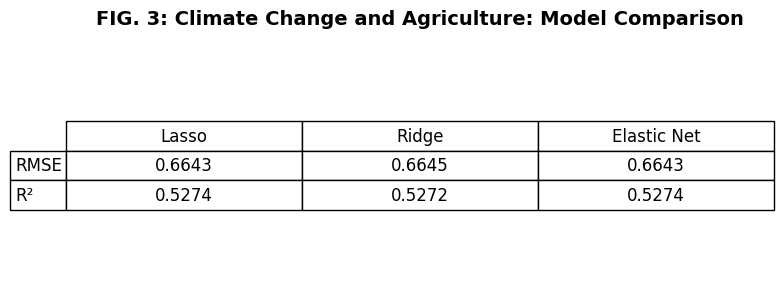

In [22]:
import matplotlib.pyplot as plt

data = [
    [round(rmse, 4), round(rmse1, 4), round(rmse3, 4)],
    [round(r2, 4), round(r21, 4), round(r23, 4)]
]

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis("off")

table = ax.table(
    cellText=data,
    rowLabels=["RMSE","R²"],
    colLabels=["Lasso", "Ridge", "Elastic Net"],
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.8)

plt.title("FIG. 3: Climate Change and Agriculture: Model Comparison", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

In [23]:
df_CO2 = pd.read_csv(r"C:\Users\thyde\Documents\OMDS Resources\DX 799 O1 Data Science Capstone\owid-co2-data.csv")
numeric_df_CO2 = df_CO2.select_dtypes(include='number') 
nona_numeric_df_CO2 = numeric_df_CO2.dropna()
clean_numeric_dfCO2 = nona_numeric_df_CO2[['gdp','co2_growth_prct','co2_per_capita','co2_per_gdp','temperature_change_from_co2']].copy()

In [24]:
# Define features (X) and target (y)
y1 = clean_numeric_dfCO2["temperature_change_from_co2"]
X1 = clean_numeric_dfCO2.drop(columns=["temperature_change_from_co2"])

# Split into train/test sets
X_train2, X_test2, y_train2, y_test2 = train_test_split(X1, y1, test_size=0.2, random_state=42)

# Create and fit Lasso model
lasso2 = Lasso(alpha=1.0, random_state=42)
lasso2.fit(X_train2, y_train2)

# Make predictions
y_pred4 = lasso2.predict(X_test2)

# Evaluate
rmse4 = np.sqrt(mean_squared_error(y_test2, y_pred4))
r24 = r2_score(y_test2, y_pred4)

print(f"RMSE: {rmse4:.4f}")
print(f"R²: {r24:.4f}")

# View coefficients (some may be zero due to L1 regularization)
print("\nCoefficients:")
print(pd.DataFrame({'Feature': X1.columns, 'Coefficient': lasso2.coef_}))

RMSE: 0.0266
R²: 0.8604

Coefficients:
           Feature   Coefficient
0              gdp  9.528586e-15
1  co2_growth_prct -0.000000e+00
2   co2_per_capita  0.000000e+00
3      co2_per_gdp  0.000000e+00


In [25]:
# Create and fit Ridge model
ridge2 = Ridge(alpha=1.0, random_state=42)
ridge2.fit(X_train2, y_train2)

# Make predictions
y_pred5 = ridge2.predict(X_test2)

# Evaluate
rmse5 = np.sqrt(mean_squared_error(y_test2, y_pred5))
r25 = r2_score(y_test2, y_pred5)

print(f"RMSE: {rmse5:.4f}")
print(f"R²: {r25:.4f}")

# View coefficients (all non-zero due to L2 regularization)
print("\nCoefficients:")
print(pd.DataFrame({'Feature': X1.columns, 'Coefficient': ridge2.coef_}))

RMSE: 0.0261
R²: 0.8655

Coefficients:
           Feature   Coefficient
0              gdp  9.543273e-15
1  co2_growth_prct -1.403395e-04
2   co2_per_capita  8.913868e-04
3      co2_per_gdp  7.230558e-03


C:\Users\thyde\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.75418e-28): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


In [26]:
# Create and fit ElasticNet model
elasticnet2 = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42)
elasticnet2.fit(X_train2, y_train2)

# Make predictions
y_pred6 = elasticnet2.predict(X_test2)

# Evaluate
rmse6 = np.sqrt(mean_squared_error(y_test2, y_pred6))
r26 = r2_score(y_test2, y_pred6)

print(f"RMSE: {rmse6:.4f}")
print(f"R²: {r26:.4f}")

# View coefficients (some may be zero due to L1 component)
print("\nCoefficients:")
print(pd.DataFrame({'Feature': X1.columns, 'Coefficient': elasticnet2.coef_}))

RMSE: 0.0266
R²: 0.8604

Coefficients:
           Feature   Coefficient
0              gdp  9.528586e-15
1  co2_growth_prct -0.000000e+00
2   co2_per_capita  0.000000e+00
3      co2_per_gdp  0.000000e+00


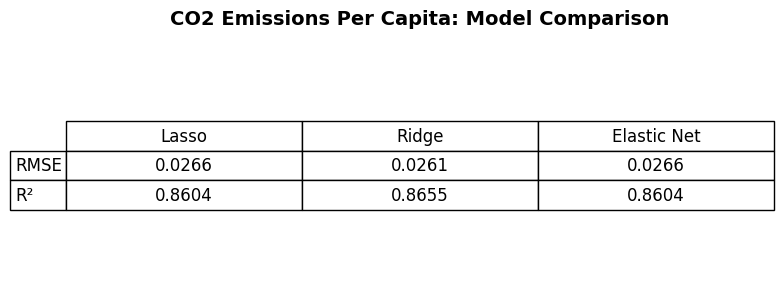

In [27]:
data = [
    [round(rmse4, 4), round(rmse5, 4), round(rmse6, 4)],
    [round(r24, 4), round(r25, 4), round(r26, 4)]
]

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis("off")

table = ax.table(
    cellText=data,
    rowLabels=["RMSE","R²"],
    colLabels=["Lasso", "Ridge", "Elastic Net"],
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.8)

plt.title("CO2 Emissions Per Capita: Model Comparison", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

In [28]:
import pandas as pd
import numpy as np